# MDR-TS v6.1 - Random Forest
**Temporal-Station Random Forest Model for Soil Moisture Prediction**

**Author:** Kerry Cheon & Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR  
**Notebook Type:** Training & Evaluation  
**Last Updated:** January 10, 2026

---

## Model Summary
- **Model Name:** MDR-TS-RF  
- **Version:** v6.1
- **Algorithm:** Random Forest Regressor
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_2.0/split_meta.json`
- **Same splits as XGBoost v3.3**

---

**What's new?**
- Using Random Forest instead of XGBoost
- Grid search over RF hyperparameters:
  - n_estimators (number of trees)
  - max_depth
  - min_samples_split
  - min_samples_leaf
  - max_features
- Same 39 derived features as v3.3

## 0. Imports

In [9]:
# !pip install numpy pandas matplotlib seaborn scikit-learn tqdm

In [10]:
import os
import json
import pickle
import random
from pathlib import Path
from datetime import datetime

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utilities
from itertools import product
from tqdm.auto import tqdm

# SHAP
import shap

# Warnings
import warnings
warnings.filterwarnings("ignore")

print("imports loaded")

np.random.seed(0)
plt.rcParams["figure.dpi"] = 120

imports loaded


## 1. Environment Setup

In [11]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")
    print(f"  Scikit-learn version: {__import__('sklearn').__version__}")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  Scikit-learn version: 1.7.2
environment setup complete


## 2. Data Access

In [13]:
# Project paths
VERSION = "v6"
SUBVERSION = "v6.1"
RUN_NAME = "mdr_ts_rf_v6_1"

# PROJECT_ROOT = "/Users/kerrycheon/PycharmProjects/MDR-Project"
PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR/"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:", os.path.exists(DATA_ROOT))
print("  splits exists:", os.path.exists(SPLIT_ROOT))
print("  output exists:", os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR/
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR//Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR//Models/Temporal/v6/v6.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [14]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_2.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_2.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_2.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/train_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/val_derived_all.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_all/test_derived_all.csv
train: dropped columns ['slope', 'elev']

train: shape=(15904, 352)
train: columns=352
val: dropped columns ['slope', 'elev']

val: shape=(3408, 352)
val: columns=352
test: dropped columns ['slope', 'elev']

test: shape=(3408, 352)
test: columns=352


## 4. Feature and Target Definition

In [16]:
# Column definitions (same as XGBoost v3.3)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
    'A_d_E_SAR_ratio_kobs1',
    'A_d_F_NDMI_kobs1',
    'A_d_G_API_kobs1',
    'A_d_LST_modis_kobs1',
    'C_smm_E_SAR_ratio_alpha0.85_n5',
    'C_smm_F_NDMI_alpha0.85_n5',
    'C_smm_G_API_alpha0.85_n5',
    'C_smm_LST_modis_alpha0.85_n5',
    'DOY',
    'D_sa_E_SAR_ratio',
    'D_sa_F_NDMI',
    'D_sa_LST_modis',
    'D_z_E_SAR_ratio',
    'D_z_F_NDMI',
    'D_z_LST_modis',
    'E_SAR_diff',
    'E_SAR_ratio',
    'F_MSI',
    'F_NDMI',
    'F_NDVI',
    'G_API',
    'G_DSLR',
    'G_DSLR_isnan',
    'G_rain_sum_30d',
    'G_rain_sum_3d',
    'G_rain_sum_7d',
    'LST_modis',
    'V_rollstd_E_SAR_ratio_kobs7',
    'V_rollstd_F_NDMI_kobs7',
    'V_rollstd_G_API_kobs7',
    'V_rollstd_LST_modis_kobs7',
    'aspect',
    'precip_mm',
    's1_vh',
    's1_vv',
    's2_b11',
    's2_b12',
    's2_b4',
    's2_b8'
]

# Validation
expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 39
  Target:   soil_moisture_5cm


## 5. Temporal Leakage Checks

In [17]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     15904
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 -- 2021-09-19

VAL
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2018-06-08 -- 2023-12-29

TEST
  rows:     3408
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2019-11-12 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

-- split locked --


## 6. Create Feature Matrices

In [18]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")

Feature matrix shapes:
  X_train: (15904, 39)
  X_val:   (3408, 39)
  X_test:  (3408, 39)
  y_train: (15904,)


## 7. Random Forest Grid Search

In [19]:
def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

# Random Forest hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
}

print("Grid search parameters:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")

total_configs = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal configurations: {total_configs}")
print("\nNote: This may take a while. Consider reducing grid size for faster results.")

Grid search parameters:
  n_estimators: [100, 200, 300, 500]
  max_depth: [10, 15, 20, 25, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2', 0.5]

Total configurations: 540

Note: This may take a while. Consider reducing grid size for faster results.


In [20]:
# Run grid search
grid = list(product(*param_grid.values()))
rows = []

pbar = tqdm(grid, desc="RF grid search", total=len(grid))
best_so_far = -np.inf

for vals in pbar:
    params = dict(zip(param_grid.keys(), vals))

    # Train model
    model = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        random_state=SEED,
        n_jobs=-1,  # Use all CPU cores
        verbose=0
    )

    model.fit(X_train, y_train)

    # Predict on validation set
    y_val_pred = model.predict(X_val)

    val_r2 = r2_score(y_val, y_val_pred)
    val_rmse = rmse(y_val, y_val_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_bias = float(np.mean(y_val.values - y_val_pred))

    rows.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_split": params["min_samples_split"],
        "min_samples_leaf": params["min_samples_leaf"],
        "max_features": params["max_features"],
        "val_R2": val_r2,
        "val_RMSE": val_rmse,
        "val_MAE": val_mae,
        "val_bias": val_bias,
    })

    if val_r2 > best_so_far:
        best_so_far = val_r2
        pbar.set_postfix(best_val_R2=f"{best_so_far:.4f}")

print("\nGrid search complete!")

RF grid search:   0%|          | 0/540 [00:00<?, ?it/s]


Grid search complete!


In [21]:
# View results
results = pd.DataFrame(rows).sort_values("val_R2", ascending=False)
print("\nTop 10 configurations:")
results.head(10)


Top 10 configurations:


,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,val_R2,val_RMSE,val_MAE,val_bias
186,200,15.0,10,4,sqrt,0.784991,0.049815,0.039274,0.009952
191,200,20.0,2,1,0.5,0.784812,0.049836,0.038569,0.010168
185,200,15.0,10,2,0.5,0.784582,0.049862,0.038485,0.010089
71,100,20.0,5,4,0.5,0.784425,0.049880,0.038623,0.009955
62,100,20.0,2,4,0.5,0.784425,0.049880,0.038623,0.009955
326,300,20.0,2,1,0.5,0.783813,0.049951,0.038627,0.010097
56,100,20.0,2,1,0.5,0.783801,0.049953,0.038814,0.010469
51,100,15.0,10,4,sqrt,0.783726,0.049961,0.039397,0.010231
377,300,25.0,10,4,0.5,0.783684,0.049966,0.038464,0.010056
461,500,20.0,2,1,0.5,0.783625,0.049973,0.038624,0.010137


## 8. Train Final Model on Best Configuration

In [22]:
# Get best hyperparameters
best = results.iloc[0].to_dict()

print("Best hyperparameters:")
print(f"  n_estimators: {best['n_estimators']}")
print(f"  max_depth: {best['max_depth']}")
print(f"  min_samples_split: {best['min_samples_split']}")
print(f"  min_samples_leaf: {best['min_samples_leaf']}")
print(f"  max_features: {best['max_features']}")
print(f"\nValidation R²: {best['val_R2']:.4f}")
print(f"Validation RMSE: {best['val_RMSE']:.4f}")

Best hyperparameters:
  n_estimators: 200
  max_depth: 15.0
  min_samples_split: 10
  min_samples_leaf: 4
  max_features: sqrt

Validation R²: 0.7850
Validation RMSE: 0.0498


In [23]:
# Combine train + val for final training
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

final_model = RandomForestRegressor(
    n_estimators=int(float(best['n_estimators'])),
    max_depth=int(float(best['max_depth'])) if best['max_depth'] != 'None' else None,
    min_samples_split=int(float(best['min_samples_split'])),
    min_samples_leaf=int(float(best['min_samples_leaf'])),
    max_features=best['max_features'],
    bootstrap=best.get('bootstrap', True),
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Training final model on train+val...")
final_model.fit(X_train_val, y_train_val)
print("Training complete!")

Training final model on train+val...
Training complete!


## 9. Evaluate on All Splits

In [24]:
# Make predictions
y_train_pred = final_model.predict(X_train)
y_val_pred = final_model.predict(X_val)
y_test_pred = final_model.predict(X_test)

# Compute metrics
def compute_metrics(y_true, y_pred, split_name):
    return {
        "split": split_name,
        "R2": r2_score(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "bias": float(np.mean(y_true.values - y_pred)),
    }

metrics = pd.DataFrame([
    compute_metrics(y_train, y_train_pred, "train"),
    compute_metrics(y_val, y_val_pred, "val"),
    compute_metrics(y_test, y_test_pred, "test"),
])

print("\n=== Model Performance ===")
print(metrics.to_string(index=False))


=== Model Performance ===
split       R2     RMSE      MAE      bias
train 0.970607 0.017458 0.012042 -0.000461
  val 0.980413 0.015035 0.010201  0.002186
 test 0.735496 0.047820 0.036235  0.014445


## 10. Feature Importance


Top 15 Most Important Features:
                     feature  importance
    C_smm_G_API_alpha0.85_n5    0.125430
                       G_API    0.112004
                         DOY    0.104482
C_smm_LST_modis_alpha0.85_n5    0.095712
              G_rain_sum_30d    0.075308
                   LST_modis    0.066708
               G_rain_sum_7d    0.037413
       V_rollstd_G_API_kobs7    0.032019
                      aspect    0.026978
               G_rain_sum_3d    0.025123
                 D_sa_F_NDMI    0.022062
                  D_z_F_NDMI    0.021661
                       s2_b8    0.021060
            D_sa_E_SAR_ratio    0.017387
             D_z_E_SAR_ratio    0.016621


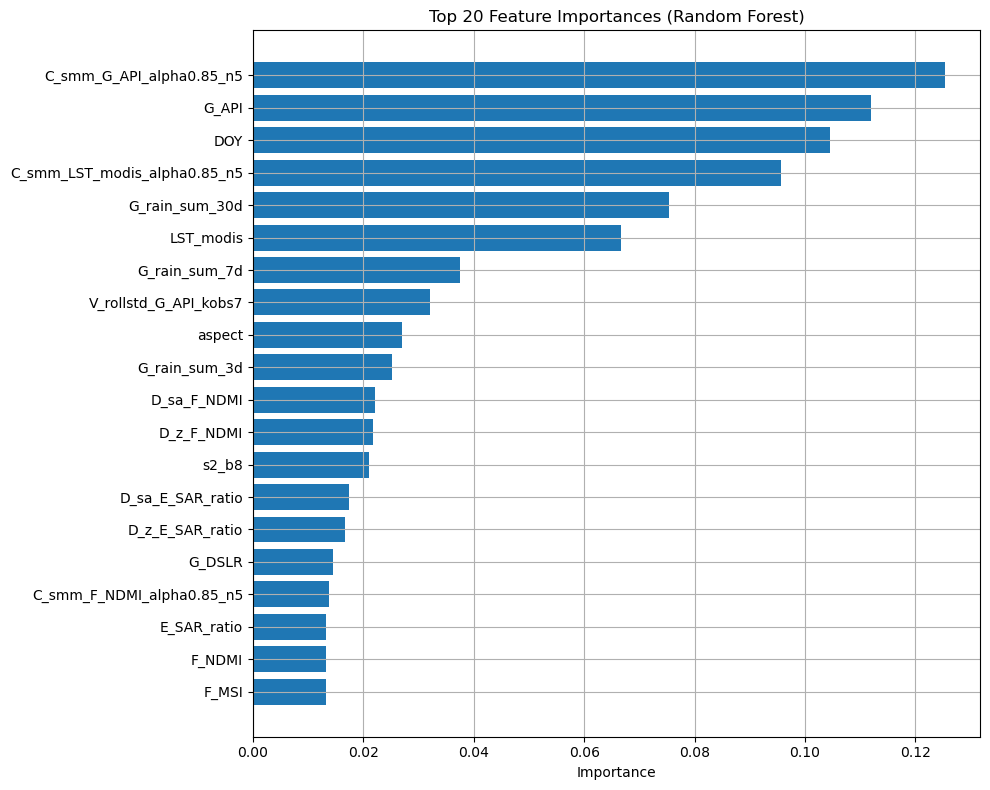

In [25]:
# Get feature importances
feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_n = 20
top_features = feature_importance.head(top_n)
plt.barh(range(top_n), top_features["importance"].values)
plt.yticks(range(top_n), top_features["feature"].values)
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Per-Station Test Performance

In [26]:
# Per-station metrics
station_metrics = []
station_ids = test_df["station_id"].values

for sid in np.unique(station_ids):
    mask = station_ids == sid
    if mask.sum() < 5:
        continue

    y_true_station = y_test.values[mask]
    y_pred_station = y_test_pred[mask]

    station_metrics.append({
        "station_id": sid,
        "n_samples": int(mask.sum()),
        "R2": r2_score(y_true_station, y_pred_station),
        "RMSE": rmse(y_true_station, y_pred_station),
        "MAE": mean_absolute_error(y_true_station, y_pred_station),
        "bias": float(np.mean(y_true_station - y_pred_station)),
    })

station_df = pd.DataFrame(station_metrics).sort_values("R2", ascending=False)
print("\n=== Per-Station Test Performance ===")
print(station_df.to_string(index=False))


=== Per-Station Test Performance ===
           station_id  n_samples       R2     RMSE      MAE      bias
              Spokane        638 0.924159 0.031725 0.023670 -0.003019
           Darrington        735 0.898136 0.027219 0.022248 -0.007210
       Touchet_WA_824        522 0.682224 0.047887 0.035303  0.026939
SourdoughGulch_WA_985        751 0.405166 0.063105 0.047067  0.005531
             Quinault        762 0.188091 0.056341 0.050211  0.050180


## 12. Bootstrap Confidence Intervals

In [27]:
# Bootstrap R² confidence intervals
rng = np.random.default_rng(SEED)
B = 2000
n = len(y_test)

boot_r2 = np.empty(B)
for b in range(B):
    idx = rng.integers(0, n, size=n)
    boot_r2[b] = r2_score(y_test.values[idx], y_test_pred[idx])

ci_lower = np.quantile(boot_r2, 0.025)
ci_upper = np.quantile(boot_r2, 0.975)

print("\n=== Bootstrap Confidence Interval (2000 iterations) ===")
print(f"Test R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"CI width: {ci_upper - ci_lower:.4f}")


=== Bootstrap Confidence Interval (2000 iterations) ===
Test R²: 0.7355
95% CI: [0.7146, 0.7546]
CI width: 0.0400


## 13. Prediction Plots

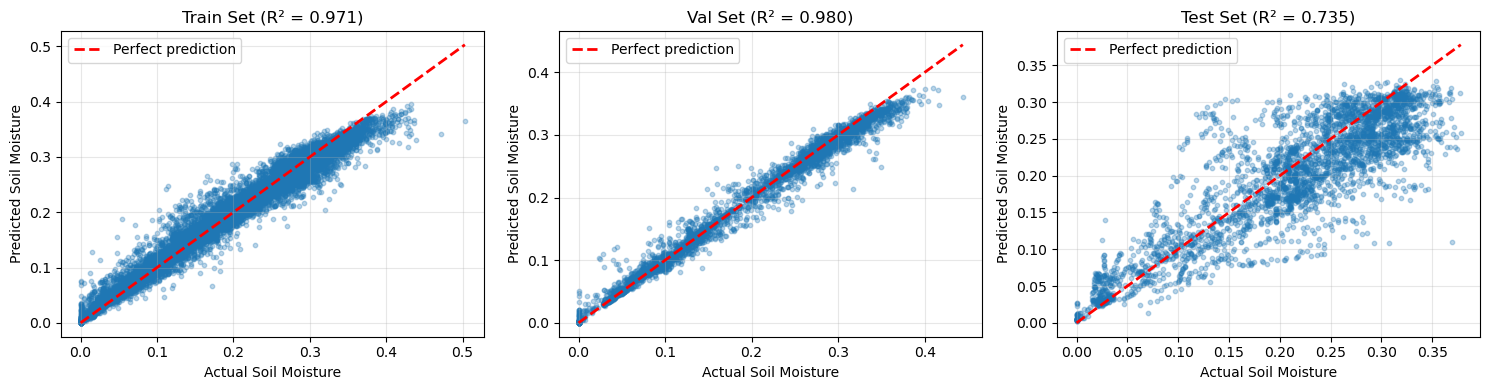

In [28]:
# Scatter plot: predicted vs actual
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

splits = [
    ("Train", y_train, y_train_pred),
    ("Val", y_val, y_val_pred),
    ("Test", y_test, y_test_pred),
]

for ax, (name, y_true, y_pred) in zip(axes, splits):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual Soil Moisture')
    ax.set_ylabel('Predicted Soil Moisture')
    ax.set_title(f'{name} Set (R² = {r2_score(y_true, y_pred):.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Save Model and Results

In [29]:
# Create timestamped run directory
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v6/v6.1/mdr_ts_rf_v6_1_20260131_113009


In [30]:
# Save model
MODEL_PATH = os.path.join(RUN_DIR, "model.pkl")
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(final_model, f)
print(f"Model saved to: {MODEL_PATH}")

# Save grid search results
GRID_RESULTS_PATH = os.path.join(RUN_DIR, "grid_search_results.csv")
results.to_csv(GRID_RESULTS_PATH, index=False)
print(f"Grid search results saved to: {GRID_RESULTS_PATH}")

# Save metrics
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
metrics.to_csv(METRICS_PATH, index=False)
print(f"Metrics saved to: {METRICS_PATH}")

# Save per-station metrics
STATION_METRICS_PATH = os.path.join(RUN_DIR, "station_metrics.csv")
station_df.to_csv(STATION_METRICS_PATH, index=False)
print(f"Station metrics saved to: {STATION_METRICS_PATH}")

# Save feature importance
FEATURE_IMP_PATH = os.path.join(RUN_DIR, "feature_importance.csv")
feature_importance.to_csv(FEATURE_IMP_PATH, index=False)
print(f"Feature importance saved to: {FEATURE_IMP_PATH}")

Model saved to: /Users/jbalkovec/Desktop/MDR//Models/Temporal/v6/v6.1/mdr_ts_rf_v6_1_20260131_113009/model.pkl
Grid search results saved to: /Users/jbalkovec/Desktop/MDR//Models/Temporal/v6/v6.1/mdr_ts_rf_v6_1_20260131_113009/grid_search_results.csv
Metrics saved to: /Users/jbalkovec/Desktop/MDR//Models/Temporal/v6/v6.1/mdr_ts_rf_v6_1_20260131_113009/metrics.csv
Station metrics saved to: /Users/jbalkovec/Desktop/MDR//Models/Temporal/v6/v6.1/mdr_ts_rf_v6_1_20260131_113009/station_metrics.csv
Feature importance saved to: /Users/jbalkovec/Desktop/MDR//Models/Temporal/v6/v6.1/mdr_ts_rf_v6_1_20260131_113009/feature_importance.csv


In [31]:
# Check if test set has different time characteristics
print("Date ranges:")
print(f"Train: {X_train.index.min()} to {X_train.index.max()}")
print(f"Val:   {X_val.index.min()} to {X_val.index.max()}")
print(f"Test:  {X_test.index.min()} to {X_test.index.max()}")

Date ranges:
Train: 0 to 15903
Val:   0 to 3407
Test:  0 to 3407


In [32]:
# Save run metadata
run_metadata = {
    "model_name": "MDR-TS-RF",
    "version": "v6.1",
    "algorithm": "RandomForest",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "best_params": {
        "n_estimators": int(best['n_estimators']),
        "max_depth": best['max_depth'],
        "min_samples_split": int(best['min_samples_split']),
        "min_samples_leaf": int(best['min_samples_leaf']),
        "max_features": best['max_features'],
        "random_state": SEED,
    },
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
    "performance": {
        "test_R2": float(r2_score(y_test, y_test_pred)),
        "test_RMSE": float(rmse(y_test, y_test_pred)),
        "test_MAE": float(mean_absolute_error(y_test, y_test_pred)),
        "bootstrap_CI_lower": float(ci_lower),
        "bootstrap_CI_upper": float(ci_upper),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")
with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print(f"Run metadata saved to: {META_PATH}")
print("\n=== All artifacts saved successfully! ===")

Run metadata saved to: /Users/jbalkovec/Desktop/MDR//Models/Temporal/v6/v6.1/mdr_ts_rf_v6_1_20260131_113009/run_metadata.json

=== All artifacts saved successfully! ===


## 15. Summary

This notebook trained a Random Forest model for soil moisture prediction using the same data splits and features as the XGBoost v3.3 model.

**Key points:**
- Same 39 derived features
- Same temporal train/val/test splits (no data leakage)
- Grid search over RF hyperparameters
- Comprehensive evaluation including per-station metrics and bootstrap CI

**Next steps:**
- Compare performance with XGBoost v3.3
- Consider ensemble methods (combining RF + XGBoost)
- Analyze feature importance differences between models

## SHAP Analysis

In [33]:
# might seem like bloat, but this is here to keep everything consistent
# + I can copy paste these cells to every other notebook

def _is_xgb(model):
    name = model.__class__.__name__.lower()
    return "xgb" in name or "xgboost" in name

def _is_rf(model):
    name = model.__class__.__name__.lower()
    return "randomforest" in name or "extratrees" in name

def _is_elasticnet(model):
    return model.__class__.__name__.lower() == "elasticnet"


def plot_heatmap(df, title):
    plt.figure(figsize=(12, 4 + 0.25 * len(df)))
    plt.imshow(df.values, aspect="auto")
    plt.yticks(range(len(df.index)), df.index)
    plt.xticks(range(len(df.columns)), df.columns, rotation=90)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [34]:
def shap_importance_block(
    models: dict,
    X_train: pd.DataFrame,
    X_eval: pd.DataFrame,
    background_size: int = 500,
    normalize: bool = True,
    top_k: int | None = 30,
    compute_corr: bool = True,
    random_state: int = 0,
):
    bg = X_train.sample(n=min(background_size, len(X_train)), random_state=random_state)

    rows = []
    for model_name, model in models.items():

        if _is_xgb(model) or _is_rf(model):
            explainer = shap.TreeExplainer(model)
        elif _is_elasticnet(model):
            explainer = shap.LinearExplainer(
                model, bg, feature_perturbation="interventional"
            )
        else:
            explainer = shap.Explainer(model.predict, bg)

        shap_values = explainer(X_eval)
        vals = shap_values.values

        if vals.ndim == 3:
            if vals.shape[1] == 2:
                vals = vals[:, 1, :]
            else:
                vals = vals.mean(axis=1)

        mean_abs = np.mean(np.abs(vals), axis=0)
        mean = np.mean(vals, axis=0)

        df = pd.DataFrame({
            "model": model_name,
            "feature": X_eval.columns,
            "mean_abs_shap": mean_abs,
            "mean_shap": mean,
        }).sort_values("mean_abs_shap", ascending=False)

        df["rank"] = np.arange(1, len(df) + 1)
        if top_k is not None:
            df = df.head(top_k)

        if normalize:
            s = df["mean_abs_shap"].sum()
            df["mean_abs_shap_norm"] = df["mean_abs_shap"] / (s if s != 0 else 1)

        rows.append(df)

    importance_long = pd.concat(rows, ignore_index=True)

    value_col = "mean_abs_shap_norm" if normalize else "mean_abs_shap"
    heatmap_wide = (
        importance_long
        .pivot_table(index="model", columns="feature", values=value_col, fill_value=0.0)
        .sort_index()
    )

    corr = X_eval.corr(method="spearman") if compute_corr else None

    return importance_long, heatmap_wide, corr

In [35]:
models = {
    "rf": final_model,
}

In [ ]:
importance_long, heatmap_wide, corr = shap_importance_block(
    models=models,
    X_train=X_train,
    X_eval=X_test,
    normalize=True,
    top_k=25,
    compute_corr=True,
)

In [ ]:
importance_long.head(10)

In [ ]:
heatmap_wide

In [ ]:
plot_heatmap(
    heatmap_wide,
    title="Models x Features (normalized mean |SHAP|)"
)

In [ ]:
if corr is not None:
    plot_heatmap(
        corr,
        title="Feature correlation (Spearman)"
    )

In [ ]:
best_model = models["rf"]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
)